<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/Zero_fiew_shot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# 1. Загрузка данных
train_df = pd.read_csv("in_domain_train.csv", sep=',')
test_df = pd.read_csv("in_domain_dev.csv", sep=',')
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [74]:
# 2. Инициализация модели и токенизатора
model_name = "ai-forever/rugpt3small_based_on_gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at ai-forever/rugpt3small_based_on_gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [75]:
# 3. Шаблоны промптов
prompt_templates = [
    "Предложение: {sentence}\nГрамматически корректно? {label}\n",
    "Текст: {sentence}\nПриемлемо с точки зрения грамматики? {label}\n",
    "Фраза: {sentence}\nСоответствует нормам русского языка? {label}\n"
]


In [76]:
# 4. Функция для создания промпта (объединена для zero-shot и few-shot)
def create_prompt(sentence, examples=None, prompt_template=None):
    if examples:  # Few-shot
        prompt = "Определите, является ли предложение грамматически корректным.\nВот несколько примеров:\n\n"
        for example in examples:
            prompt += prompt_template.format(sentence=example['sentence'], label="Да" if example['acceptable'] == 1 else "Нет") + "\n"
        prompt += "Теперь ваша очередь:\n"
        prompt += prompt_template.format(sentence=sentence, label="")
        prompt += "Ответ:"
    else:  # Zero-shot
        prompt = f"Определите грамматическую корректность предложения: '{sentence}' Ответ:"
    return prompt

In [77]:
# 5. Функция предсказания
def predict(model, tokenizer, prompt, device="cpu"):
    model.to(device)
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    predicted_class = torch.argmax(logits, dim=-1).item()
    return predicted_class, probabilities[1]


In [78]:
# 6. Оценка модели
def evaluate_model(model, tokenizer, test_df, prompt_template, num_examples, device="cpu"):
    y_true = test_df['acceptable'].values
    y_pred = []
    y_prob = []

    for index, row in test_df.iterrows():
        sentence = row['sentence']

        # Создание примеров для few-shot, если num_examples > 0
        few_shot_examples = None
        if num_examples > 0:
            positive_examples = train_df[train_df['acceptable'] == 1].sample(min(num_examples // 2, len(train_df[train_df['acceptable'] == 1])))
            negative_examples = train_df[train_df['acceptable'] == 0].sample(min(num_examples // 2, len(train_df[train_df['acceptable'] == 0])))
            few_shot_examples = pd.concat([positive_examples, negative_examples]).sample(frac=1)
            few_shot_examples = few_shot_examples.to_dict('records')  # Список словарей

        # Создание промпта в зависимости от режима (zero-shot или few-shot)
        prompt = create_prompt(sentence, few_shot_examples, prompt_template) if num_examples > 0 else create_prompt(sentence)

        # Предсказание с использованием созданного промпта
        prediction, prob = predict(model, tokenizer, prompt, device)

        y_pred.append(prediction)
        y_prob.append(prob)

    print(classification_report(y_true, y_pred, zero_division=0))
    print(confusion_matrix(y_true, y_pred))

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()



Используемый prompt_template: Предложение: {sentence}
Грамматически корректно? {label}


Количество примеров: 0
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


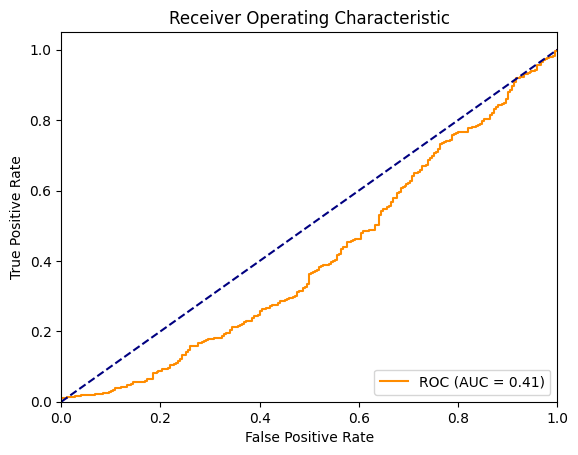


Количество примеров: 1
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


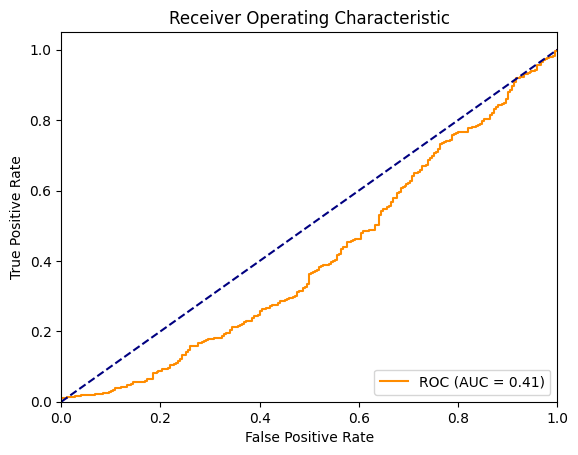


Количество примеров: 2
              precision    recall  f1-score   support

           0       0.24      0.16      0.20       250
           1       0.74      0.82      0.78       733

    accuracy                           0.66       983
   macro avg       0.49      0.49      0.49       983
weighted avg       0.62      0.66      0.63       983

[[ 41 209]
 [129 604]]


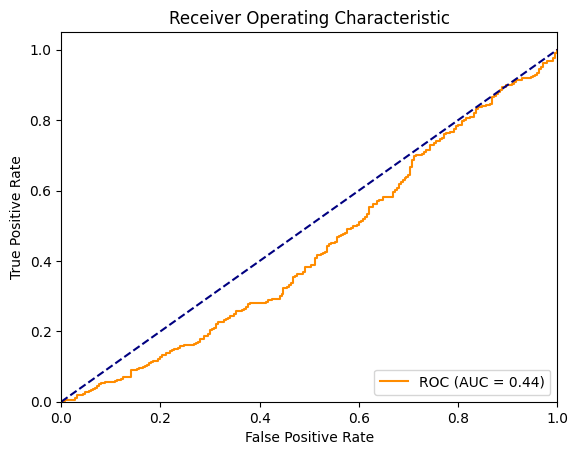


Количество примеров: 3
              precision    recall  f1-score   support

           0       0.21      0.14      0.17       250
           1       0.74      0.82      0.78       733

    accuracy                           0.65       983
   macro avg       0.47      0.48      0.47       983
weighted avg       0.60      0.65      0.62       983

[[ 35 215]
 [130 603]]


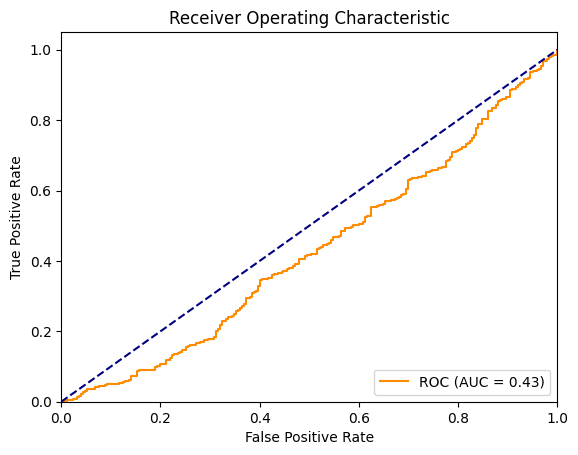


Количество примеров: 4
              precision    recall  f1-score   support

           0       0.21      0.14      0.17       250
           1       0.74      0.83      0.78       733

    accuracy                           0.65       983
   macro avg       0.48      0.48      0.47       983
weighted avg       0.60      0.65      0.62       983

[[ 34 216]
 [126 607]]


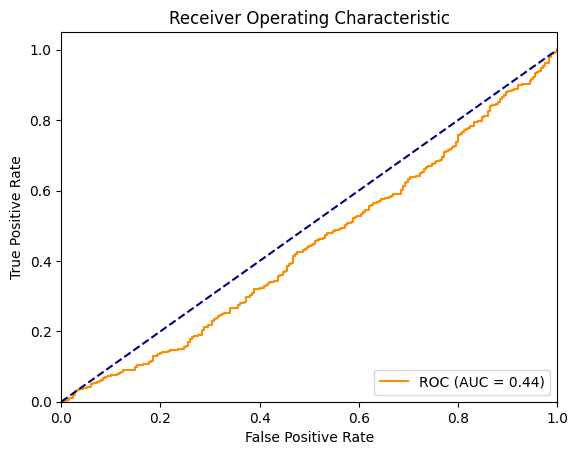


Используемый prompt_template: Текст: {sentence}
Приемлемо с точки зрения грамматики? {label}


Количество примеров: 0
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


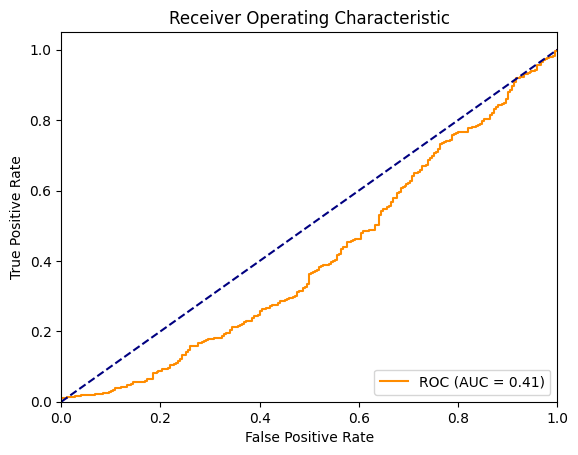


Количество примеров: 1
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


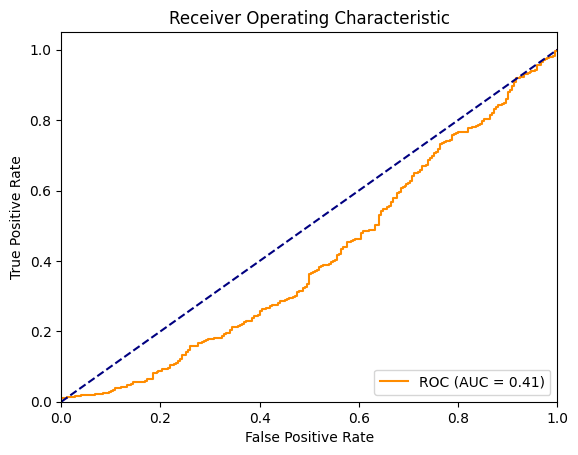


Количество примеров: 2
              precision    recall  f1-score   support

           0       0.23      0.10      0.14       250
           1       0.74      0.89      0.81       733

    accuracy                           0.69       983
   macro avg       0.49      0.49      0.47       983
weighted avg       0.61      0.69      0.64       983

[[ 24 226]
 [ 79 654]]


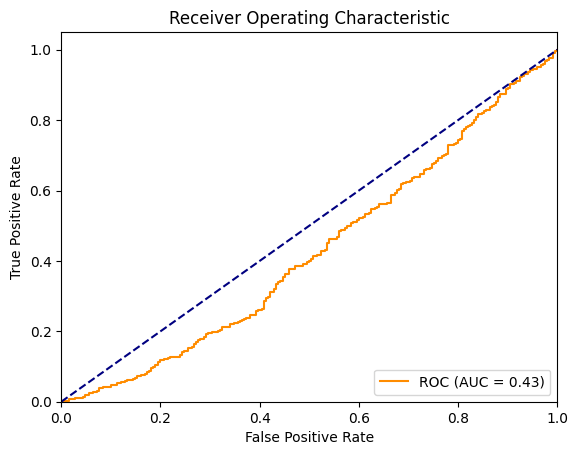


Количество примеров: 3
              precision    recall  f1-score   support

           0       0.23      0.08      0.12       250
           1       0.74      0.90      0.82       733

    accuracy                           0.70       983
   macro avg       0.49      0.49      0.47       983
weighted avg       0.61      0.70      0.64       983

[[ 21 229]
 [ 70 663]]


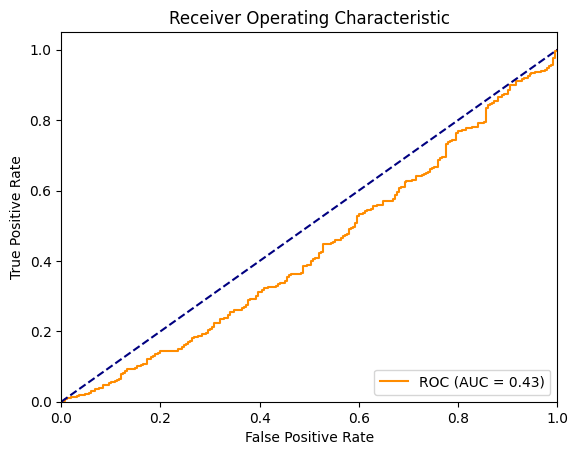


Количество примеров: 4
              precision    recall  f1-score   support

           0       0.23      0.08      0.11       250
           1       0.74      0.91      0.82       733

    accuracy                           0.70       983
   macro avg       0.49      0.49      0.47       983
weighted avg       0.61      0.70      0.64       983

[[ 19 231]
 [ 64 669]]


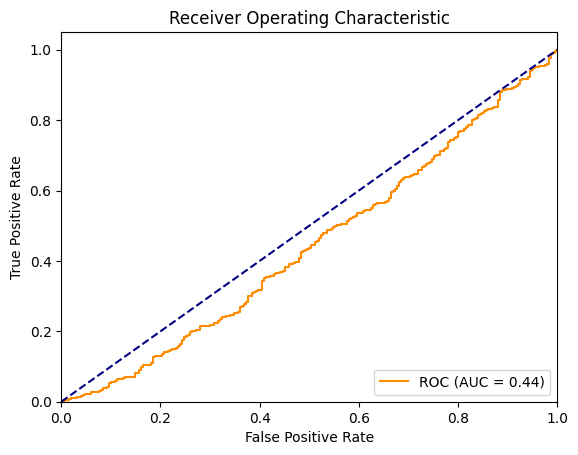


Используемый prompt_template: Фраза: {sentence}
Соответствует нормам русского языка? {label}


Количество примеров: 0
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


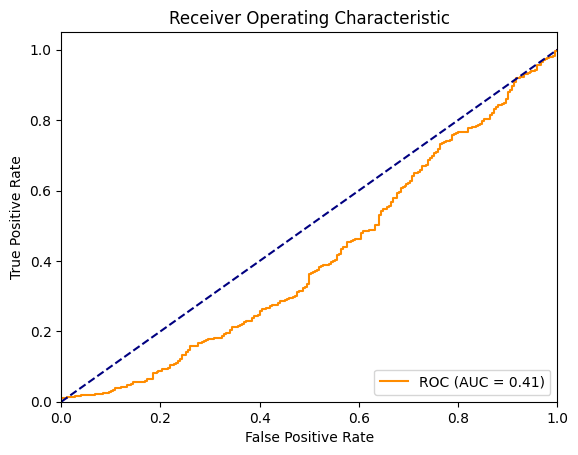


Количество примеров: 1
              precision    recall  f1-score   support

           0       0.22      0.04      0.07       250
           1       0.74      0.95      0.84       733

    accuracy                           0.72       983
   macro avg       0.48      0.50      0.45       983
weighted avg       0.61      0.72      0.64       983

[[ 10 240]
 [ 35 698]]


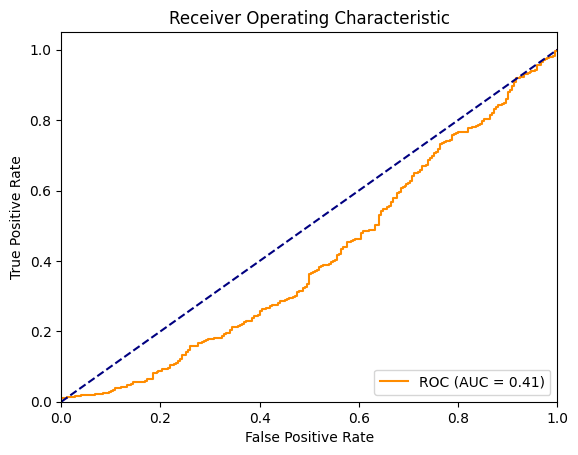


Количество примеров: 2
              precision    recall  f1-score   support

           0       0.24      0.10      0.14       250
           1       0.74      0.90      0.81       733

    accuracy                           0.69       983
   macro avg       0.49      0.50      0.48       983
weighted avg       0.62      0.69      0.64       983

[[ 24 226]
 [ 74 659]]


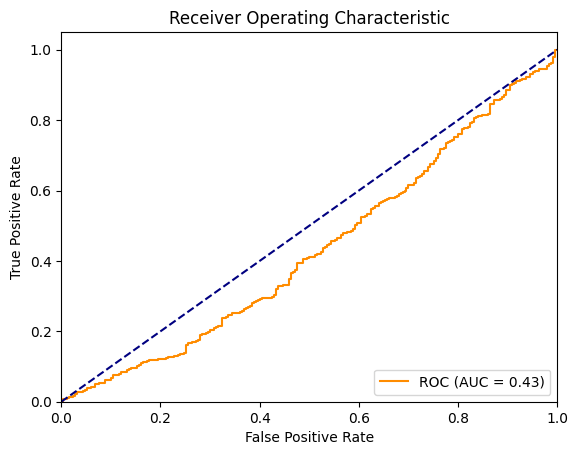


Количество примеров: 3
              precision    recall  f1-score   support

           0       0.20      0.08      0.12       250
           1       0.74      0.89      0.81       733

    accuracy                           0.68       983
   macro avg       0.47      0.49      0.46       983
weighted avg       0.60      0.68      0.63       983

[[ 21 229]
 [ 82 651]]


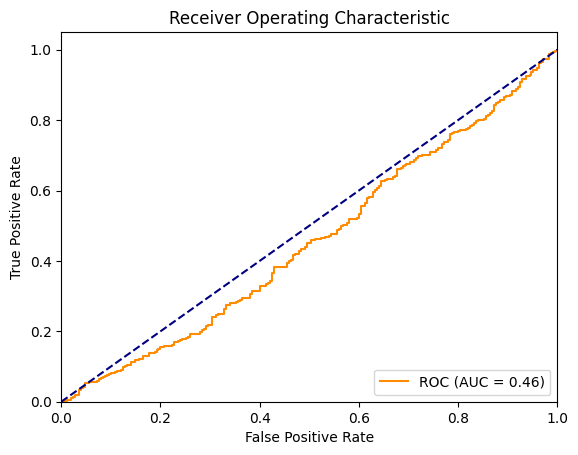


Количество примеров: 4
              precision    recall  f1-score   support

           0       0.21      0.09      0.13       250
           1       0.74      0.88      0.81       733

    accuracy                           0.68       983
   macro avg       0.48      0.49      0.47       983
weighted avg       0.61      0.68      0.63       983

[[ 23 227]
 [ 85 648]]


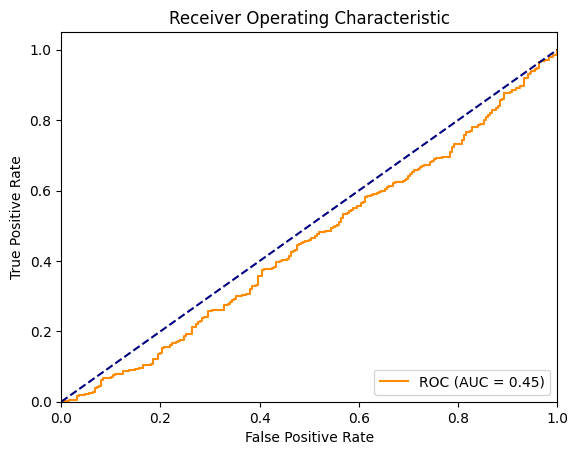

In [79]:
# 7. Запуск экспериментов
device = "cuda" if torch.cuda.is_available() else "cpu"

for prompt_template in prompt_templates:
    print(f"\nИспользуемый prompt_template: {prompt_template}")
    for num_examples in range(5):  # 0, 1, 2, 3, 4 (0 - zero-shot)
        print(f"\nКоличество примеров: {num_examples}")
        evaluate_model(model, tokenizer, test_df, prompt_template, num_examples, device)